# Практика. Разведочный анализ

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

>#### Задание 1
Прочитайте файл `cosmetology`.

In [2]:
df = pd.read_csv('data/cosmetology.csv')
df

,order_id,client_age,gender,procedure_price,procedure_duration,master_rating,return_visits,satisfaction_score
0,ID0165,35.0,male,2699.16,70,low,4,5.0
1,ID0771,18.0,male,899.75,28,top,8,10.0
2,ID0756,37.0,female,2801.23,75,top,7,8.0
3,ID0873,28.0,female,2888.61,89,med,5,8.0
4,ID0688,48.0,male,2478.22,58,top,10,9.0
...,...,...,...,...,...,...,...,...
995,ID0015,NaN,female,2699.25,72,low,2,5.0
996,ID0611,28.0,male,1892.76,45,low,7,8.0
997,ID0331,38.0,male,NaN,31,med,9,3.0
998,ID0007,30.0,male,1706.80,35,med,10,8.0


#### Контекст

Сеть салонов красоты. Собираются данные о процедурах, стоимости, длительности, возрасте клиента, рейтинге мастера, количестве повторных визитов.

#### Признаки датасета

- order_id — ID заказа (str),
- client_age — возраст клиента (float),
- gender — пол клиента (str),
- procedure_price — стоимость процедуры (руб.) (float),
- procedure_duration — длительность процедуры (мин) (int),
- master_rating — рейтинг мастера (low/mad/top)	(str),
- return_visits — количество повторных визитов за полгода (int),
- satisfaction_score — оценка удовлетворённости (1–10) (int)

#### Особенности, заложенные в данные при генерации

1) Чем выше рейтинг мастера, тем выше оценка удовлетворенности и количество повторных визитов за полгода.
2) Женщин в два раза больше, чем мужчин.
3) Чем выше продолжительность процедуры, тем выше ее стоимость.
4) Чем старше женщина, тем ниже ее удовлетворенность.
5) Чем старше мужчина, тем выше его удовлетворённость.
6) Мужчины более склонны возвращаться к мастеру, чем женщины.
7) В среднем женщины моложе мужчин.

#### Пропуски, заложенные в данные при генерации

1) Возраст не указывают 5% женщин и 2% мужчин. 
2) Стоимость процедуры не указана у 10% записей, длительность которых относится к четвертому квартилю. А среди остальных процедур не указана стоимость у 2% записей.
3) Оценку не указывают 20% женщин старше 55 лет. Среди остальных оценок пропуски составляют 1%.

#### Выбросы, заложенные в данные при генерации

1) Стоимость — несколько запредельно высоких цифр и несколько нулей (меньше 1%, можно просто удалить, это ошибка ввода).
2) Количество повторных визитов за полгода — пусть в среднем это будет примерно 3–5, но иногда доходит до 12 (IQR покажет выброс, но это нормально, удалять нельзя).


>#### Задание 2
>Проведите первичный осмотр данных. Напишите резюме.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   order_id            1000 non-null   object 
 1   client_age          960 non-null    float64
 2   gender              1000 non-null   object 
 3   procedure_price     957 non-null    float64
 4   procedure_duration  1000 non-null   int64  
 5   master_rating       1000 non-null   object 
 6   return_visits       1000 non-null   int64  
 7   satisfaction_score  989 non-null    float64
dtypes: float64(3), int64(2), object(3)
memory usage: 62.6+ KB


In [4]:
df.describe()

,client_age,procedure_price,procedure_duration,return_visits,satisfaction_score
count,960.000000,957.000000,1000.000000,1000.000000,989.000000
mean,35.792708,2403.198977,58.372000,6.528000,7.375126
std,10.582500,2830.926196,19.463361,2.655611,1.762126
min,18.000000,0.000000,15.000000,0.000000,2.000000
25%,28.000000,1821.590000,45.000000,5.000000,6.000000
50%,35.000000,2256.460000,59.000000,6.000000,7.000000
75%,43.000000,2658.960000,71.000000,8.000000,9.000000
max,71.000000,49066.194160,124.000000,15.000000,10.000000


In [5]:
df['gender'].value_counts()

female    685
male      315
Name: gender, dtype: int64

In [6]:
df['master_rating'].value_counts()

med    362
low    337
top    301
Name: master_rating, dtype: int64

**Резюме.** Женщин в два раза больше, чем мужчин. Требуется обработка пропусков в полях: возраст, цена процедуры и оценка удовлетворонности. Есть очевидные выбросы в цене.

>#### Задание 3
>Проведите обработку пропусков. Обоснуйте выбор того или иного способы обработки (удалить, заменить на среднее, заменить на среднее по группе и т. д.).

**Пропуски по возрасту.** Скорее всего, это неслучайные пропуски категории MNAR: женщины часто скрывают свой возраст, при этом женщин больше, чем мужчин, то есть возраст не указан, потому что это возраст. Бороться с этим мы не можем. Поэтому просто удаляем, тем более, что таких пропусков немного.

In [7]:
df = df.dropna(subset=['client_age']).copy()
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 960 entries, 0 to 999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   order_id            960 non-null    object 
 1   client_age          960 non-null    float64
 2   gender              960 non-null    object 
 3   procedure_price     919 non-null    float64
 4   procedure_duration  960 non-null    int64  
 5   master_rating       960 non-null    object 
 6   return_visits       960 non-null    int64  
 7   satisfaction_score  949 non-null    float64
dtypes: float64(3), int64(2), object(3)
memory usage: 67.5+ KB


**Пропуски в цене.** Проверяем, не связаны ли пропуски со значениями других переменных.

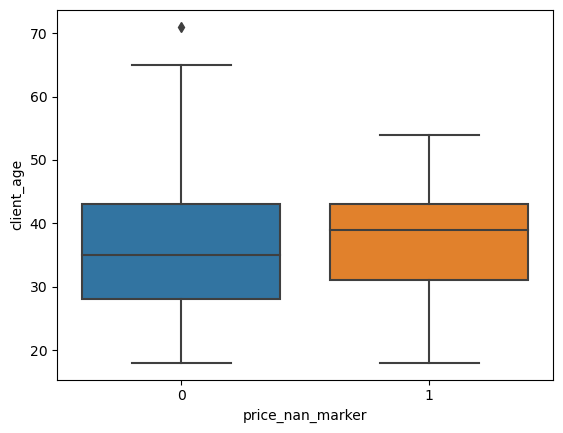

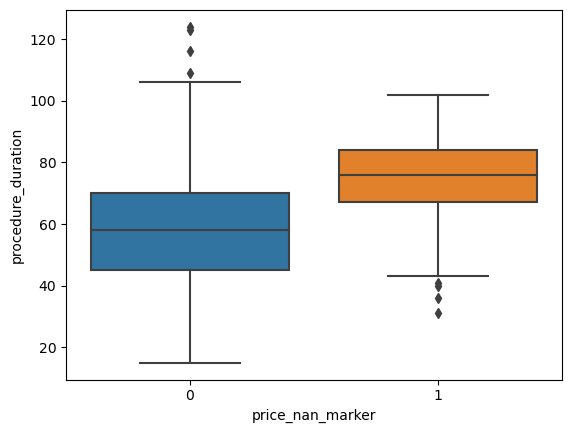

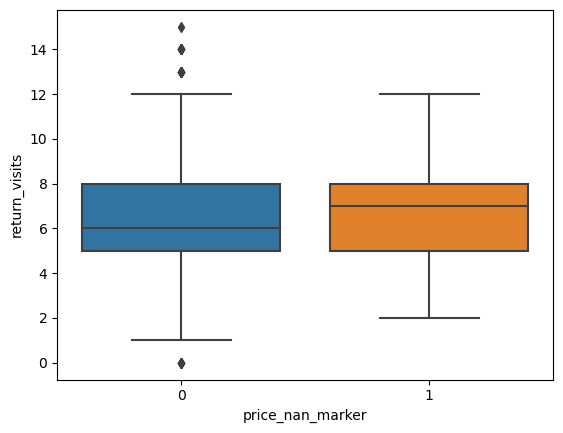

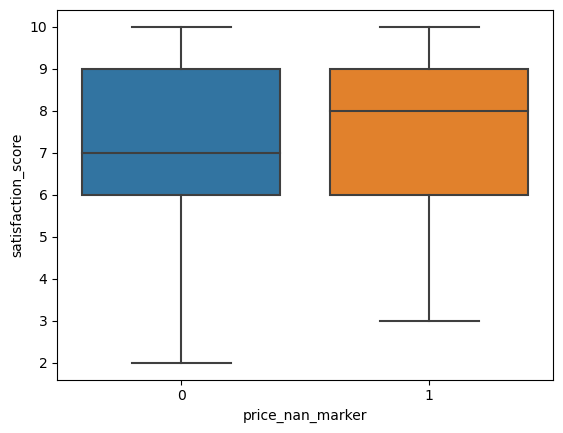

In [8]:
# Создаем категориальный признак — маркер пропуска
df['price_nan_marker'] = df['procedure_price'].isna().astype(int)

# Прогоняем картинку в цикле
for col in ['client_age', 'procedure_duration', 'return_visits', 'satisfaction_score']:
    sns.boxplot(data=df, x='price_nan_marker', y=col)
    plt.show()
    
# Удаляем ставший ненужным столбец с маркером

df = df.drop(columns = ['price_nan_marker'])

Видим, что есть связь с продолжительностью процедуры. Поэтому при заполнении пропусков используем не общую медиану, а медиану четвертого квартиля.

Создаем еще один маркер: для верхнего квартиля времени.

In [9]:
q3 = df.describe().loc['75%']['procedure_duration']

def time_marker(row):
    if row['procedure_duration'] >= q3:
        return 'long_time'
    else:
        return 'other'
    
df['time_marker'] = df.apply(time_marker, axis=1)
df

,order_id,client_age,gender,procedure_price,procedure_duration,master_rating,return_visits,satisfaction_score,time_marker
0,ID0165,35.0,male,2699.16,70,low,4,5.0,other
1,ID0771,18.0,male,899.75,28,top,8,10.0,other
2,ID0756,37.0,female,2801.23,75,top,7,8.0,long_time
3,ID0873,28.0,female,2888.61,89,med,5,8.0,long_time
4,ID0688,48.0,male,2478.22,58,top,10,9.0,other
...,...,...,...,...,...,...,...,...,...
994,ID0665,25.0,female,2641.51,77,low,2,5.0,long_time
996,ID0611,28.0,male,1892.76,45,low,7,8.0,other
997,ID0331,38.0,male,NaN,31,med,9,3.0,other
998,ID0007,30.0,male,1706.80,35,med,10,8.0,other


Выполяем группировку по маркеру времени и агрегацию по медиане цены:

In [10]:
instruction = {'procedure_price' : 'median'}
grouped = df.groupby('time_marker').agg(instruction)
grouped

,procedure_price
time_marker,
long_time,2904.745
other,2031.950


Выделяем нужную нам медиану. И производим заливку (после чего удаляем ставший ненужным маркер):

In [11]:
q3_median = grouped.loc['long_time']['procedure_price']

df['procedure_price'] = df['procedure_price'].fillna(q3_median)

df = df.drop(columns = ['time_marker'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 960 entries, 0 to 999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   order_id            960 non-null    object 
 1   client_age          960 non-null    float64
 2   gender              960 non-null    object 
 3   procedure_price     960 non-null    float64
 4   procedure_duration  960 non-null    int64  
 5   master_rating       960 non-null    object 
 6   return_visits       960 non-null    int64  
 7   satisfaction_score  949 non-null    float64
dtypes: float64(3), int64(2), object(3)
memory usage: 67.5+ KB


**Пропуски по оценкам.** Действем аналогично предыдущему пункту. Сначала создаем маркер пропусков, затем просматриваем все числовые признаки. К вонце удаляем ставиший ненужным маркер пропусков.

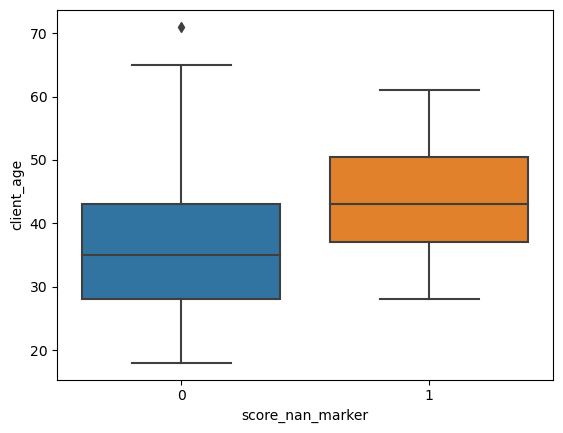

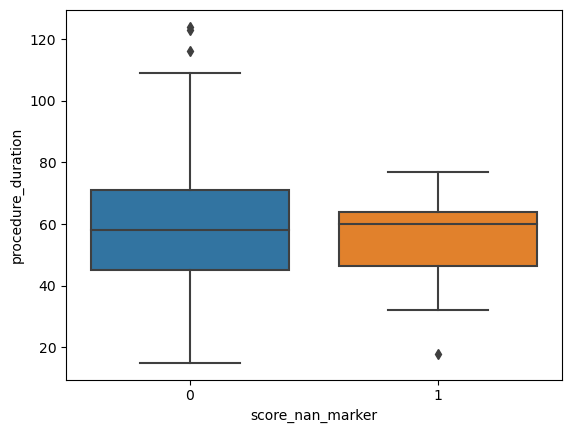

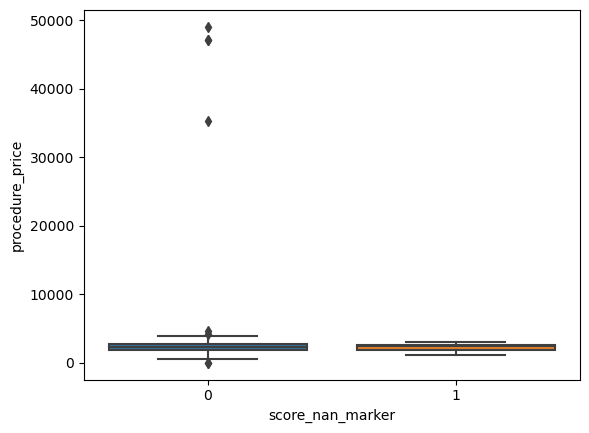

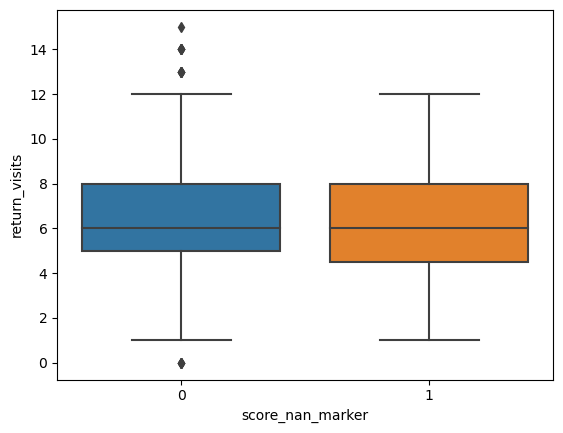

In [12]:
df['score_nan_marker'] = df['satisfaction_score'].isna().astype(int)

for col in ['client_age', 'procedure_duration', 'procedure_price', 'return_visits']:
    sns.boxplot(data=df, x='score_nan_marker', y=col)
    plt.show()
    
# Удаляем ставший ненужным столбец с маркером

df = df.drop(columns = ['score_nan_marker'])

Видим зависимость от возраста.  Поэтому при заполнении пропусков будем использовать не общую медиану, а медиану верхней половины возрастов.

Создаем еще один маркер: для верхней половины возрастов.

In [13]:
q2 = df.describe().loc['50%']['client_age']

def age_marker(row):
    if row['client_age'] >= q2:
        return 'old'
    else:
        return 'young'
    
df['age_marker'] = df.apply(age_marker, axis=1)
df

,order_id,client_age,gender,procedure_price,procedure_duration,master_rating,return_visits,satisfaction_score,age_marker
0,ID0165,35.0,male,2699.160,70,low,4,5.0,old
1,ID0771,18.0,male,899.750,28,top,8,10.0,young
2,ID0756,37.0,female,2801.230,75,top,7,8.0,old
3,ID0873,28.0,female,2888.610,89,med,5,8.0,young
4,ID0688,48.0,male,2478.220,58,top,10,9.0,old
...,...,...,...,...,...,...,...,...,...
994,ID0665,25.0,female,2641.510,77,low,2,5.0,young
996,ID0611,28.0,male,1892.760,45,low,7,8.0,young
997,ID0331,38.0,male,2904.745,31,med,9,3.0,old
998,ID0007,30.0,male,1706.800,35,med,10,8.0,young


Выполяем группировку по маркеру возраста и агрегацию по медиане оценки:

In [14]:
instruction = {'satisfaction_score' : 'median'}
grouped = df.groupby('age_marker').agg(instruction)
grouped

,satisfaction_score
age_marker,
old,7.0
young,7.0


И видим, что нет никакой разницы. То есть, пропускают оценку чаще старые, чем молодые. Но если ставят, то ставят то же самое.

Поэтому с чистой совестью все заполняем общей медианой.

In [15]:
df['satisfaction_score'] = df['satisfaction_score'].fillna(df['satisfaction_score'].median())

df = df.drop(columns = ['age_marker'])

df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 960 entries, 0 to 999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   order_id            960 non-null    object 
 1   client_age          960 non-null    float64
 2   gender              960 non-null    object 
 3   procedure_price     960 non-null    float64
 4   procedure_duration  960 non-null    int64  
 5   master_rating       960 non-null    object 
 6   return_visits       960 non-null    int64  
 7   satisfaction_score  960 non-null    float64
dtypes: float64(3), int64(2), object(3)
memory usage: 67.5+ KB


>#### Задание 3
>Проведите обработку выбросов. Обоснуйте выбор того или иного способы обработки (удалить, не удалять, заменить и т. д.).

В цикле применяем IQR:

In [16]:
cols = ['client_age', 'procedure_price', 'procedure_duration', 'return_visits', 'satisfaction_score']

for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(col, ':', len(outliers), 'выбросов')
    print(outliers[col])
    print('')

client_age : 1 выбросов
199    71.0
Name: client_age, dtype: float64

procedure_price : 8 выбросов
116    47094.192214
269    49066.194160
518        0.000000
580     4247.350000
656    35360.025698
669    47170.389061
804        0.000000
826     4697.670000
Name: procedure_price, dtype: float64

procedure_duration : 3 выбросов
112    116
580    123
826    124
Name: procedure_duration, dtype: int64

return_visits : 18 выбросов
100    14
146     0
163    14
186    15
209     0
213    13
237    14
441    13
508     0
659    13
670    14
725    14
739    13
777     0
807    13
851    14
902     0
938    13
Name: return_visits, dtype: int64

satisfaction_score : 0 выбросов
Series([], Name: satisfaction_score, dtype: float64)



Помимо IQR для уверенности рисуем еще гистограммы:

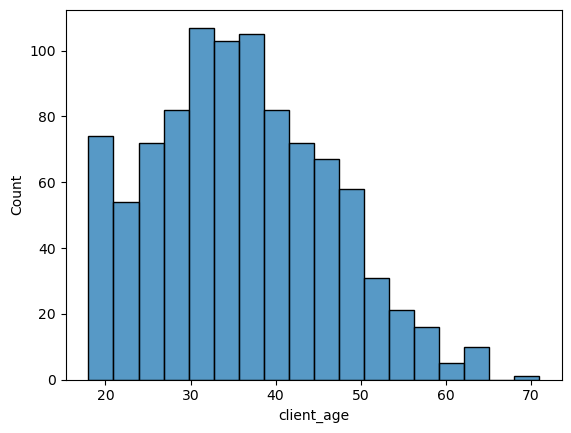

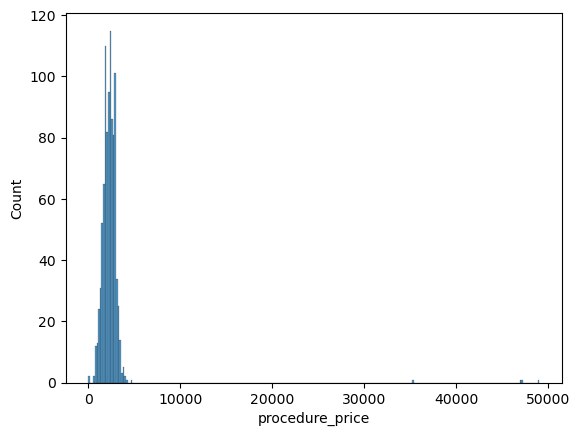

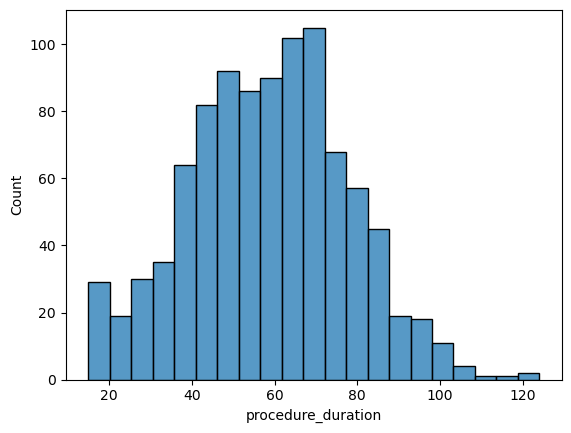

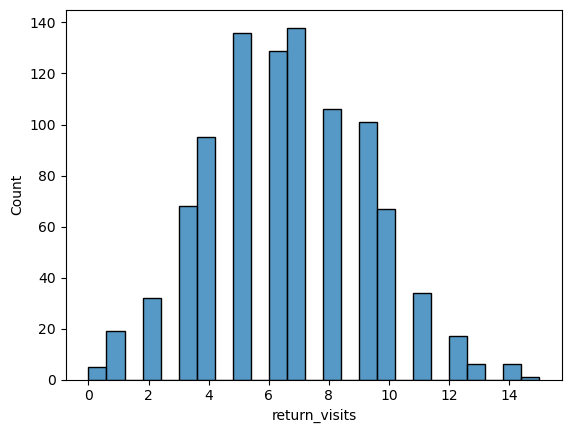

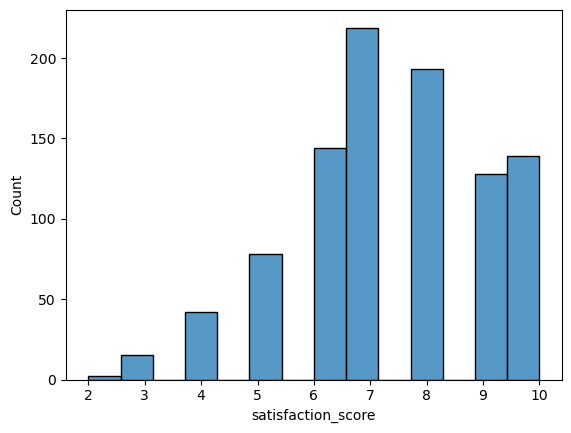

In [17]:
for col in ['client_age', 'procedure_price', 'procedure_duration', 'return_visits', 'satisfaction_score']:
    sns.histplot(data=df, x=col)
    plt.show()

Понимаем, что выбросы есть только в цене, и что они таковы, что  проще всего их удалить. Но. Среди отфильтрованных цен есть и вполне нормальные (около 4000). Их оставляем. А запредельно большие и нули — удаляем. 

In [18]:
mask = (df['procedure_price'] == 0) | (df['procedure_price'] > 30000)
df = df.loc[~mask]
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 954 entries, 0 to 999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   order_id            954 non-null    object 
 1   client_age          954 non-null    float64
 2   gender              954 non-null    object 
 3   procedure_price     954 non-null    float64
 4   procedure_duration  954 non-null    int64  
 5   master_rating       954 non-null    object 
 6   return_visits       954 non-null    int64  
 7   satisfaction_score  954 non-null    float64
dtypes: float64(3), int64(2), object(3)
memory usage: 67.1+ KB


**Наводим порядок.** И в завершение приводим данные к нужным нам типам.

In [19]:
df['client_age'] = df['client_age'].astype(int)
df['satisfaction_score'] = df['satisfaction_score'].astype(int)
df['procedure_price'] = round(df['procedure_price'], 2)
df = df.reset_index(drop=True)
df

,order_id,client_age,gender,procedure_price,procedure_duration,master_rating,return_visits,satisfaction_score
0,ID0165,35,male,2699.16,70,low,4,5
1,ID0771,18,male,899.75,28,top,8,10
2,ID0756,37,female,2801.23,75,top,7,8
3,ID0873,28,female,2888.61,89,med,5,8
4,ID0688,48,male,2478.22,58,top,10,9
...,...,...,...,...,...,...,...,...
949,ID0665,25,female,2641.51,77,low,2,5
950,ID0611,28,male,1892.76,45,low,7,8
951,ID0331,38,male,2904.74,31,med,9,3
952,ID0007,30,male,1706.80,35,med,10,8


>#### Задание 4
>Сформулируйте 5 гипотез относительно имеющихся данных. Проверьте их при помощи визуализаций.

**Гипотеза 1.** Чем выше рейтинг мастера, тем выше удовлетворенность клиентов.

<Axes: xlabel='master_rating', ylabel='satisfaction_score'>

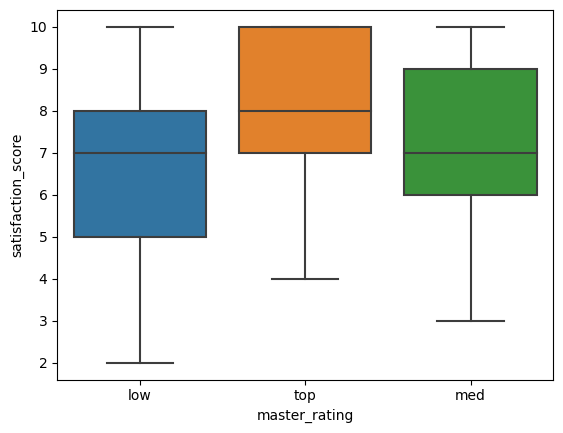

In [20]:
sns.boxplot(data=df, x='master_rating', y='satisfaction_score')

**Вывод.** Гипотеза пожтверждена.

**Гипотеза 2**. Чем выше рейтинг мастера, тем чаще к нему возвращаются клиенты.

<Axes: xlabel='master_rating', ylabel='return_visits'>

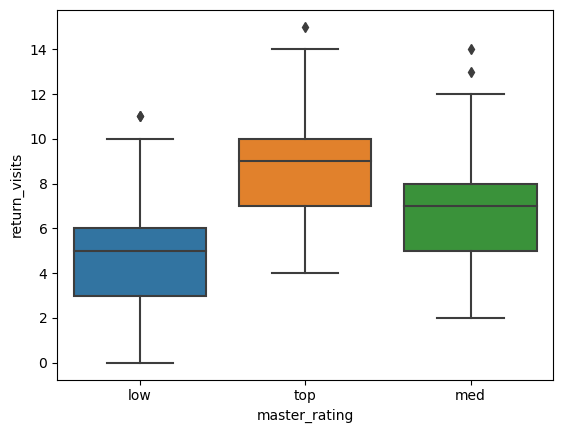

In [21]:
sns.boxplot(data=df, x='master_rating', y='return_visits')

**Вывод.** Гипотеза подтверждена.

**Гипотеза 3.** Чем выше рейтинг мастера, тем выше стоимость услуги.

<Axes: xlabel='master_rating', ylabel='procedure_price'>

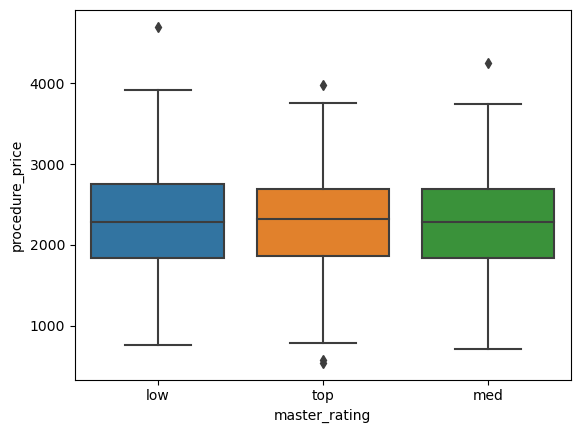

In [22]:
sns.boxplot(data=df, x='master_rating', y='procedure_price')

**Вывод.** Гипотеза не подтаерждена.

**Гипотеза 4.** Возраст клиента влияет на его удовлетворенность.

<Axes: xlabel='client_age', ylabel='satisfaction_score'>

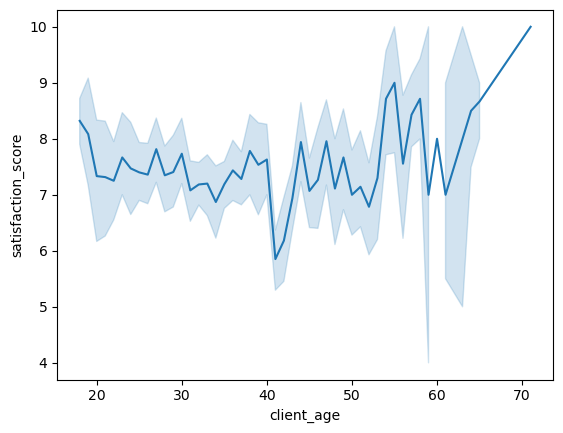

In [23]:
sns.lineplot(data=df, x='client_age', y='satisfaction_score')#, hue='gender')

**Вывод.** Гипотеза не подтверждена.

**Гипотеза 5.** Мужчины с возрастом начинают ставить более высокие оценки, а женщины — наоборот: более низкие.

<Axes: xlabel='client_age', ylabel='satisfaction_score'>

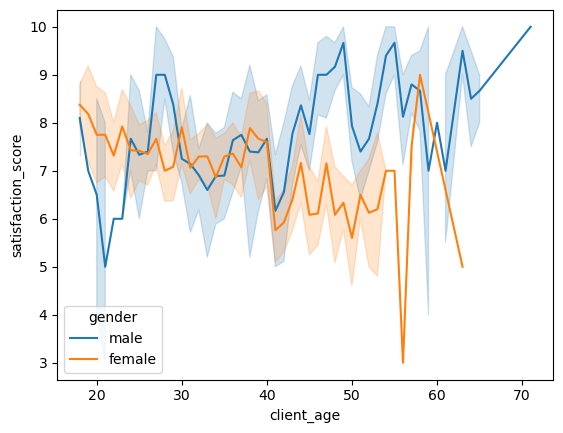

In [24]:
sns.lineplot(data=df, x='client_age', y='satisfaction_score', hue='gender')

**Вывод.** Гипотеза подтверждена.

**Гипоотеза 6.** Мужчины более склонны возвращаться к мастеру, нежели женщины.

<Axes: xlabel='gender', ylabel='return_visits'>

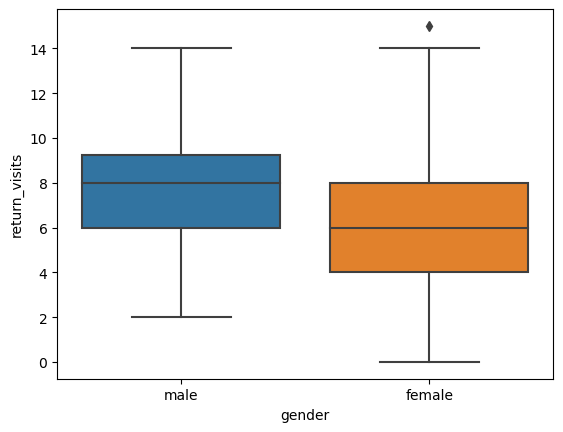

In [25]:
sns.boxplot(data=df, x='gender', y='return_visits')

## Домашнее задание

>#### Задание 1
Прочитайте датасет `fitnes`.

In [30]:
df = pd.read_csv('data/fitnes.csv')
df

,client_id,age,gender,membership_type,monthly_fee,avg_visits_per_week,trainer_rating,avg_session_duration,weight_change_kg,member_satisfaction
0,ESS4D,31,female,morning,1256.41,2.8,mid,52.0,NaN,8.0
1,IVU2T,22,female,day,1957.88,2.6,junior,64.0,NaN,6.0
2,011VI,38,male,morning,1391.10,4.4,senior,48.0,-0.1,7.0
3,WD3Q3,32,female,morning,1678.17,4.1,mid,25.0,NaN,6.0
4,YYHJ9,38,female,full,2916.40,2.6,junior,46.0,NaN,7.0
...,...,...,...,...,...,...,...,...,...,...
995,BJV9Z,36,female,vip,6704.97,4.7,elite,65.0,-3.2,6.0
996,6TFVP,29,female,day,2010.91,4.3,elite,48.0,0.7,7.0
997,NPWS5,17,female,morning,1538.71,3.4,mid,22.0,NaN,8.0
998,AO983,26,male,day,2029.57,3.0,mid,57.0,-6.5,7.0


#### Контекст

Сеть фитнес-клубов. Данные о тренировках, абонементах, посещаемости и прогрессе клиентов.

#### Признаки

- client_id — ID клиента (str, 5 символов),

- age — возраст (16–75) (int),

- gender — пол (male / female / non-binary) (str),

- membership_type — тип абонемента (morning / day / full / vip) (str),

- monthly_fee — ежемесячная плата (руб., float, 2 знака после запятой),

- avg_visits_per_week — среднее количество посещений в неделю (float),

- trainer_rating — рейтинг тренера (junior / mid / senior / elite) (str),

- avg_session_duration — средняя длительность тренировки (мин) (int),

- weight_change_kg — изменение веса за полгода (кг, float, может быть отрицательным) (float),

- member_satisfaction — удовлетворённость клубом (1–10) (int).


#### Особенности, заложенные в данные при генерации

- Чем выше рейтинг тренера, тем выше удовлетворённость и чаще посещения.

- Обладатели VIP-абонементов ходят реже, но платят больше (ценят гибкость).

- Чем старше клиент, тем меньше изменение веса (как положительное, так и отрицательное).

- Женщины предпочитают утренние абонементы, мужчины — дневные.

- Чем дольше тренировка, тем больше изменение веса (положительное или отрицательное, в зависимости от цели).

- Посетители с высоким рейтингом тренера реже уходят (больше среднего посещений).


#### Пропуски, заложенные в данные при генерации

- Изменение веса отсутствует у 30% новых клиентов (меньше 3 месяцев), так как им ещё рано оценивать. Среди остальных — 5%.

- Удовлетворённость не указана у 10% записей (случайно, MCAR).

- Средняя длительность тренировки не указана у 8% записей клиентов с VIP-абонементом (не хотят фиксировать время), у остальных — 1%.


#### Выбросы, заложенные в данные при генерации

- Ежемесячная плата: несколько значений ниже 50 рублей (ошибка ввода, менее 0.5%, удалить).

- Посещения в неделю: у клиентов с VIP-абонементом бывает до 1 посещения в неделю, у энтузиастов — до 14 — это норма, удалять нельзя.

- Изменение веса: несколько экстремальных значений (например, –30 кг за полгода — единичный случай, но возможен, оставить для обсуждения студентами).


>#### Задание 2
Обработайте пропуски.

In [27]:
# Код

>#### Задание 3
Обработайте выбросы.

In [28]:
# Код

>#### Задание 4
Сформулируйте и визуализируйте 5 гипотез.

In [29]:
# Код